# Dataset stats (raw labels)


In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from aitraf.data_ops.schema import LabelsSchema

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
LABELS_PATH = DATA_DIR / "labels.jsonl"
PLOTS_DIR = PROJECT_ROOT / "notebooks" / "data" / "dataset-stats"

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")

In [22]:
len(labels_df)

689

In [12]:
labels_df = pd.read_json(LABELS_PATH, lines=True, dtype=LabelsSchema.types)
labels_df.head()


video annotation_id annotator  \
0  s3://aitraf/clips/25-10-31 19-46-26 5688-00.00...           132         1   
1  s3://aitraf/clips/IMG_5683-00.06.44.747-00.06....           133         1   
2  s3://aitraf/clips/25-10-31 19-54-19 5689-00.12...           134         1   
3  s3://aitraf/clips/25-10-31 19-54-19 5689-00.08...           135         1   
4  s3://aitraf/clips/25-11-07 16-03-18 5701-00.04...           136         1   

    id                        created_at                        updated_at  \
0  446  2025-11-09 19:11:00.868564+00:00  2025-12-20 16:04:31.440764+00:00   
1  646  2025-11-09 19:11:22.857860+00:00  2025-12-30 15:40:29.090789+00:00   
2  489  2025-11-09 19:11:45.189362+00:00  2025-12-30 15:40:06.889504+00:00   
3  482  2025-11-09 19:11:56.773045+00:00  2025-12-30 15:38:42.621260+00:00   
4  572  2025-11-09 19:12:12.130420+00:00  2025-12-30 15:38:10.853372+00:00   

   lead_time       trick key_foot    person  execution_score  \
0    165.569        soul    right  Henrikas                2   
1     36.481  fs-savanah    right  Henrikas                2   
2    101.479     ao-soul    right  Henrikas                2   
3     39.935       mizou    right  Henrikas                1   
4     27.763  fs-savanah    right       Max                2   

0                         confident, but very short   
1    Looks really good, just too short and too slow.  
2  Too short and too slow, even with reverse 360 ...  
3              Really short. Barely counts as grind.  
4                          Very short, and very slow

In [13]:
def save_plot(fig, name):
    path = PLOTS_DIR / f"{name}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    return path


## Trick distribution


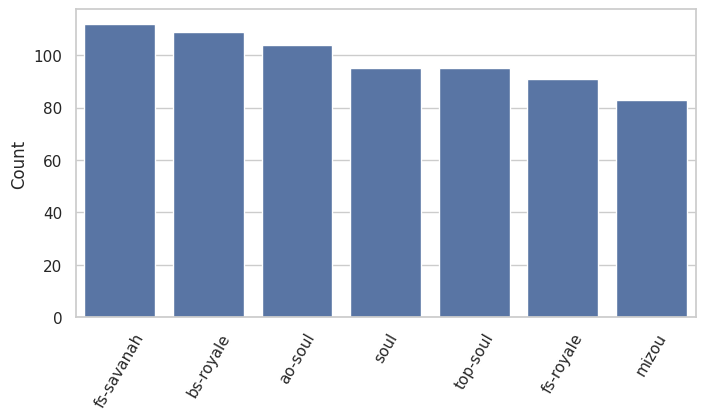

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(data=labels_df, x="trick", order=labels_df["trick"].value_counts().index, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=60)
save_plot(fig, "trick_dist")
plt.show()


## Ratings distribution


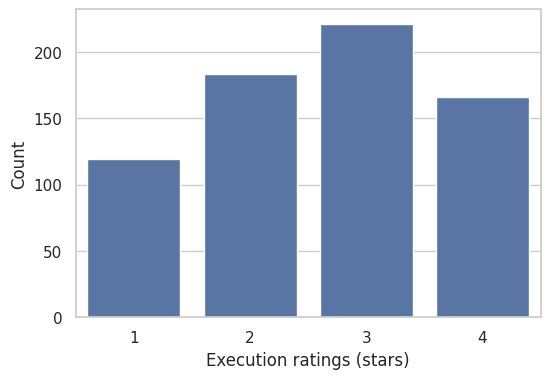

In [15]:
ratings = labels_df["execution_score"].dropna()
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x=ratings, order=sorted(ratings.unique()), ax=ax)
ax.set_xlabel("Execution ratings (stars)")
ax.set_ylabel("Count")
save_plot(fig, "ratings_dist")
plt.show()


## Person distribution


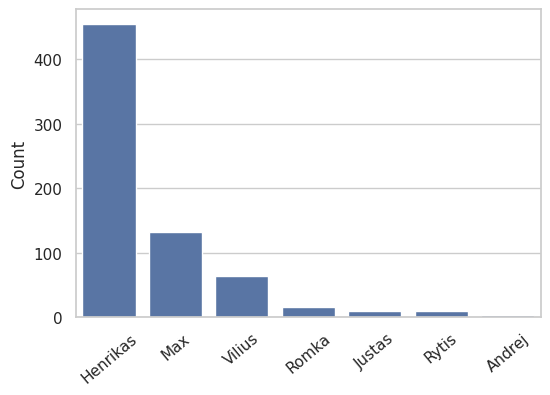

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=labels_df, x="person", order=labels_df["person"].value_counts().index, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=40)
save_plot(fig, "person_dist")
plt.show()


## Key foot distribution


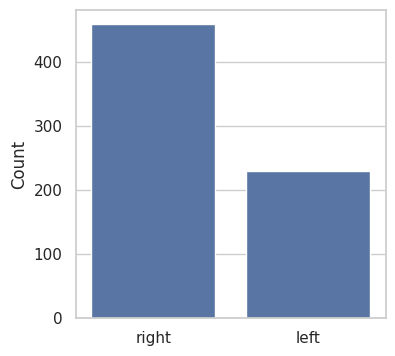

In [17]:
fig, ax = plt.subplots(figsize=(4, 4))
sns.countplot(data=labels_df, x="key_foot", order=labels_df["key_foot"].value_counts().index, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Count")
save_plot(fig, "key_foot_dist")
plt.show()


## Clip duration distribution


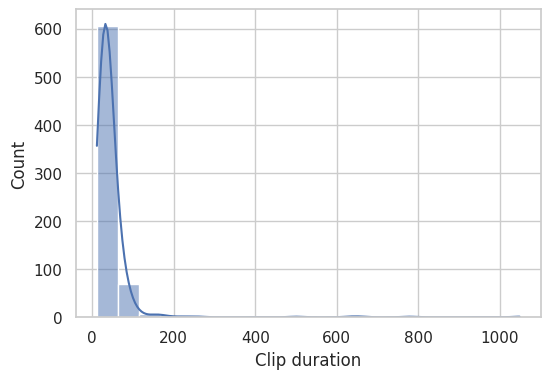

In [18]:
durations = labels_df["lead_time"].dropna()
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(durations, bins=20, kde=True, ax=ax)
ax.set_xlabel("Clip duration")
ax.set_ylabel("Count")
save_plot(fig, "clip_duration_dist")
plt.show()


## Trick vs skater heatmap


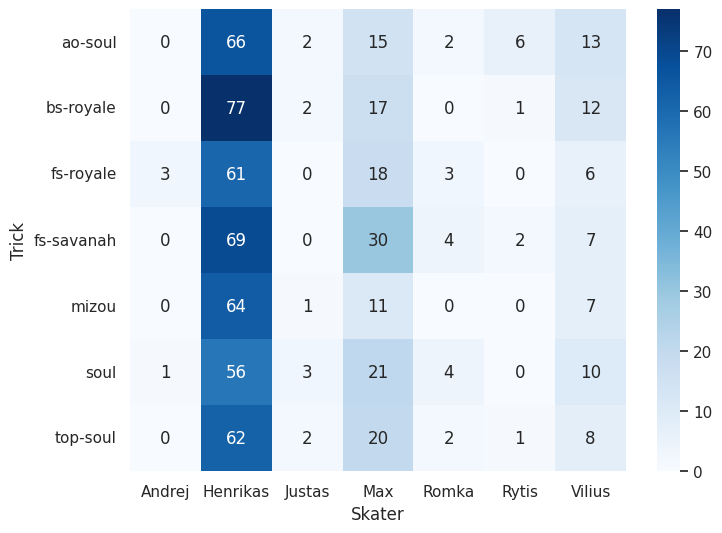

In [19]:
heatmap_df = (
    labels_df
    .groupby(["trick", "person"])
    .size()
    .reset_index(name="count")
)
heatmap_pivot = heatmap_df.pivot(index="trick", columns="person", values="count").fillna(0)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(heatmap_pivot, annot=True, fmt=".0f", cmap="Blues", ax=ax)
ax.set_xlabel("Skater")
ax.set_ylabel("Trick")
save_plot(fig, "trick_skater_heatmap")
plt.show()


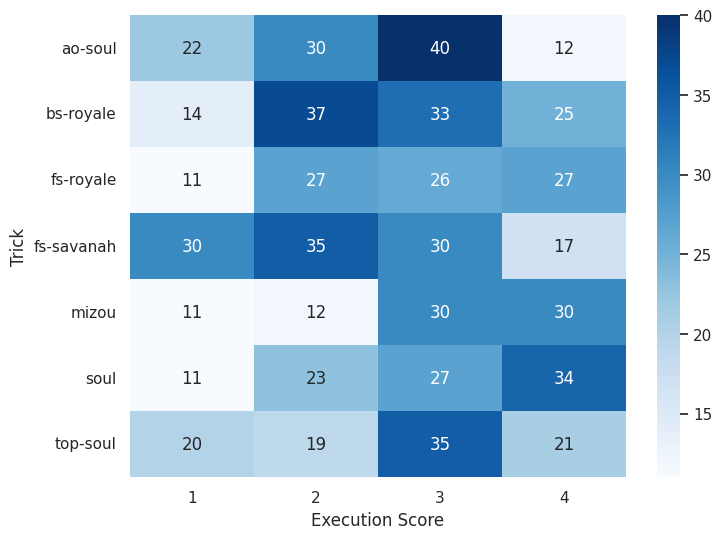

In [20]:
heatmap_df = (
    labels_df
    .groupby(["trick", "execution_score"])
    .size()
    .reset_index(name="count")
)
heatmap_pivot = heatmap_df.pivot(index="trick", columns="execution_score", values="count").fillna(0)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(heatmap_pivot, annot=True, fmt=".0f", cmap="Blues", ax=ax)
ax.set_xlabel("Execution Score")
ax.set_ylabel("Trick")
save_plot(fig, "trick_execution_score_heatmap")
plt.show()
